In [81]:
from src.helpers.model_matrix import build_model_matrix_from_wrds

tickers_list = [
    'AAPL', 'NVDA', 'MSFT', 'AMZN', 'TSLA', 'META',
    # 'GOOGL', 'AVGO', 'GOOG', 'LLY', 'WMT', 'JPM', 'SPY', 'BRK', 'IVV',
    # 'VOO', 'V', 'MA', 'XOM', 'ORCL', 'UNH', 'VTI', 'COST', 'PG', 'HD', 'NFLX', 'BRK', 'JNJ', 'BAC', 'CRM', 'QQQ','ABBV',
    # 'KO', 'CVX', 'TMUS', 'MRK', 'CSCO', 'WFC', 'ACN', 'NOW', 'TSM', 'AXP', 'PEP', 'MCD', 'IBM', 'MS', 'DIS', 'LIN',
    # 'TMO', 'ABT', 'AMD', 'ADBE', 'PM', 'ISRG', 'GE', 'GS', 'INTU', 'CAT', 'TXN', 'QCOM', 'RY', 'VZ', 'DHR', 'BKNG', 'T', 'PLTR',
    # 'BLK', 'VUG', 'SPGI', 'RTX', 'PFE', 'NEE', 'HON', 'CMCSA', 'PGR', 'AMGN', 'LOW', 'ANET', 'UNP', 'SYK', 'TJX', 'VEA',
    # 'C', 'AMAT', 'BA', 'SCHW', 'BSX', 'KKR', 'ETN', 'SHOP', 'COP', 'VTV', 'UBER', 'BX', 'BND', 'AGG', 'PANW', 'ADP',
    # 'IEFA', 'FI'
]

all_stocks = build_model_matrix_from_wrds(
    wrds_user="jbernatchez",
    start="2016-01-01",
    end="2021-01-01",
    chunk_size=500_000,
    tickers=tickers_list,
    use_run="last"  # "new", "last", or a specific folder name (i.e. "run_20250914_133747")
)

[info] Using run folder: run_20250923_174828 (reuse=True)
[info] Reuse mode: all required Parquet files are present. No extraction performed.
{'run_folder': 'wrds_extracts\\run_20250923_174828', 'reuse': True, 'artifacts': {'dsf.parquet': 'wrds_extracts\\run_20250923_174828\\dsf.parquet', 'stocknames.parquet': 'wrds_extracts\\run_20250923_174828\\stocknames.parquet', 'ff.parquet': 'wrds_extracts\\run_20250923_174828\\ff.parquet', 'ibes_stats.parquet': 'wrds_extracts\\run_20250923_174828\\ibes_stats.parquet', 'ibes_act.parquet': 'wrds_extracts\\run_20250923_174828\\ibes_act.parquet'}}


[info] Removed 0 permnos(companies) for having zero in cfacpr or cfacshr
[info] Removed 0 permnos(companies) for exceeding the threshold of negative prices
[info] ibes_stats: 274,942 (official_ticker, stat_date) pairs have >1 row (multiple horizons/periodicities). Will collapse before join.
[info] df_prices(+ibes): 95.2% missing in n_analysts.
[info] df_prices(+ibes): 95.2% missing in cons_mean.
[info] df_prices(+ibes): 95.7% missing in cons_stdev.
[info] df_prices(+ibes): 95.7% missing in cons_cv.
[info] ibes_act: 126 (oftic, anndats) pairs have >1 row (periodicity/dup loads). Will collapse before join.
[info] df_prices(+ibes_act): 98.4% missing in act_value.
[info] ibes_act announcement time top values:
anntims
16:01:00    18
16:20:00    17
16:30:00    16
16:05:00     9
16:13:00     5
Name: count, dtype: int64
[INFO] percentage of rows removed due to leading NaNs : 1.6680%  remove reason: after forward filling empty cells
INFO: No NaN values remain after forward fill and dropping lea

In [82]:
from src.helpers.model_matrix import align_and_fill_dates_across_tickers

df = align_and_fill_dates_across_tickers(all_stocks=all_stocks)

All groups have consistent date indices and 1162 rows each.
(5855, 41)
                column  n_null  pct_null  has_nulls
0               ticker       0       0.0      False
1        adjclose_lead       0       0.0      False
2           adj_mktcap       0       0.0      False
3                  vol       0       0.0      False
4                 retx       0       0.0      False
5           n_analysts       0       0.0      False
6                 n_up       0       0.0      False
7               n_down       0       0.0      False
8            cons_mean       0       0.0      False
9          cons_median       0       0.0      False
10          cons_stdev       0       0.0      False
11           cons_high       0       0.0      False
12            cons_low       0       0.0      False
13             cons_cv       0       0.0      False
14      cons_range_pct       0       0.0      False
15       adjclose_lag0       0       0.0      False
16       adjclose_lag1       0       0.0     

In [83]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

random.seed(42)

# The data is now loaded in `df` with MultiIndex (permno, date)
# Columns: ticker, adjclose_lead (target), all features

print(f"Data shape: {df.shape}")
print(f"Index: {df.index.names}")
print(f"Columns (first 10): {df.columns.tolist()[:10]}...")

Data shape: (5810, 41)
Index: ['permno', 'date']
Columns (first 10): ['ticker', 'adjclose_lead', 'adj_mktcap', 'vol', 'retx', 'n_analysts', 'n_up', 'n_down', 'cons_mean', 'cons_median']...


In [84]:
# Setup: Create classification target and prepare train/test splits
# From main.ipynb setup (using same data)

# Define train/test split dates
TRAIN_END = pd.Timestamp('2018-12-31')
TEST_START = pd.Timestamp('2019-01-01')

tau_label = 0.0  # Classification threshold
fixedWindow = True
initial = 145
horizon = 40
step = 20

# Sort by date and ticker for consistency
panel = df.sort_index(level=['date', 'permno'])

# Get feature columns (everything except ticker and adjclose_lead)
feature_cols = [c for c in panel.columns if c not in ['ticker', 'adjclose_lead']]

# Create classification target (DIR: -1, 0, +1)
DIR = pd.Series(0, index=panel.index, dtype=int)
DIR.loc[panel["adjclose_lead"] > tau_label] = +1
DIR.loc[panel["adjclose_lead"] < -tau_label] = -1

# For this classification notebook, we'll use simple binary (0=down, 1=up)
direction_lead = (panel["adjclose_lead"] > 0).astype(int)

# Calculate simple returns from log returns (adjclose_lead is log return)
simple_ret = (np.exp(panel["adjclose_lead"]) - 1.0).rename('simple_return')

# Create working panel with features and target
panel_work = panel[feature_cols + ['adjclose_lead']].dropna().copy()

# Prepare train/test split
train_mask = panel_work.index.get_level_values('date') <= TRAIN_END
test_mask = panel_work.index.get_level_values('date') >= TEST_START

train = panel_work.loc[train_mask]
test = panel_work.loc[test_mask]

X_train_full = train[feature_cols].copy()
X_test_full = test[feature_cols].copy()
y_train = direction_lead.loc[train_mask].copy()
y_test = direction_lead.loc[test_mask].copy()

print(f"Train observations: {len(X_train_full):,}")
print(f"Test observations: {len(X_test_full):,}")
print(f"Features available: {len(feature_cols)}")
print(f"Up class (train): {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")
print(f"Down class (train): {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")


Train observations: 3,290
Test observations: 2,520
Features available: 39
Up class (train): 1,761 (53.5%)
Down class (train): 1,529 (46.5%)


## Chapter 4 Logistic Regression Baseline (Daily Data)

In [85]:

TRAIN_END = pd.Timestamp('2018-12-31')
TEST_START = pd.Timestamp('2019-01-01')

print(f"Train ends: {TRAIN_END.date()} | Test starts: {TEST_START.date()}")


Train ends: 2018-12-31 | Test starts: 2019-01-01


### Prepare Feature Matrix and Train/Test Split

### Rolling Window Cross-Validation for Indicator Selection
Using the training sample, we evaluate each indicator with a rolling (sliding) window time-series cross-validation scheme. Each fold trains on prior observations and validates on the subsequent block, mirroring the forecasting workflow.


In [86]:
CV_CONFIG = {
    'target_folds': 6,
    'min_folds': 3,
    'prescreen_folds': 3,
    'prescreen_top_k': 6,
    'error_tolerance': 1e-3,
}


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

def rolling_window_slices(n_samples: int, train_size: int, test_size: int, step: int):
    slices = []
    start = 0
    while True:
        train_end = start + train_size
        test_end = train_end + test_size
        if test_end > n_samples:
            break
        slices.append((slice(start, train_end), slice(train_end, test_end)))
        start += step
    return slices

def make_classification_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('logit', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])

def cv_error(feature_set, slices, X_cv, y_cv):
    if not slices:
        raise ValueError('No CV slices provided.')
    errors = []
    for train_slice, test_slice in slices:
        X_tr = X_cv.iloc[train_slice][feature_set]
        y_tr = y_cv.iloc[train_slice]
        X_te = X_cv.iloc[test_slice][feature_set]
        y_te = y_cv.iloc[test_slice]
        model = make_classification_pipeline()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        error = 1.0 - accuracy_score(y_te, preds)  # Use error rate instead of accuracy
        errors.append(error)
    return float(np.mean(errors)), errors

# Prepare CV data
X_cv = X_train_full.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)

n_samples = len(X_cv)
if n_samples < 120:
    raise ValueError('Not enough training observations for rolling window CV.')

test_window = max(30, min(63, n_samples // 5))
train_window = max(3 * test_window, min(504, n_samples - test_window))
if train_window + test_window > n_samples:
    train_window = max(test_window + 10, n_samples - test_window)
step_size = max(test_window // 2, 1)

cv_slices_full = rolling_window_slices(n_samples, train_window, test_window, step_size)
if len(cv_slices_full) < CV_CONFIG['min_folds']:
    raise ValueError('Rolling window configuration produced fewer than the required folds.')

target_folds = min(len(cv_slices_full), CV_CONFIG['target_folds'])
if target_folds <= 0:
    target_folds = len(cv_slices_full)
selected_idx = sorted(set(int(i) for i in np.linspace(0, len(cv_slices_full) - 1, num=target_folds, dtype=int)))
cv_slices = [cv_slices_full[i] for i in selected_idx]

prescreen_fold_count = min(len(cv_slices), CV_CONFIG['prescreen_folds'])
cv_slices_prescreen = cv_slices[:prescreen_fold_count]

print(
    f"Rolling CV folds (full={len(cv_slices_full)}, used={len(cv_slices)}), train_window={train_window}, test_window={test_window}"
)

# Forward feature selection
base_features = [f for f in ['adjclose_lag0', 'adjclose_lag1', 'adjclose_lag2', 'adjclose_lag3'] if f in X_train_full.columns]
indicator_candidates = [f for f in feature_cols if f not in base_features]

selection_history = []
current_features = base_features.copy()
current_error, _ = cv_error(current_features, cv_slices, X_cv, y_cv)
selection_history.append({'step': 0, 'added_feature': None, 'cv_error': current_error})

remaining_features = indicator_candidates.copy()
cv_candidate_ranking = pd.DataFrame()
error_tolerance = CV_CONFIG['error_tolerance']
prescreen_top_k = CV_CONFIG['prescreen_top_k']

while remaining_features:
    prescreen_scores = []
    for feature in remaining_features:
        trial_features = current_features + [feature]
        error, _ = cv_error(trial_features, cv_slices_prescreen, X_cv, y_cv)
        prescreen_scores.append({'feature': feature, 'cv_error': error})
    prescreen_df = pd.DataFrame(prescreen_scores).sort_values('cv_error').reset_index(drop=True)
    shortlist = prescreen_df['feature'].tolist()
    if prescreen_top_k is not None:
        shortlist = shortlist[:min(prescreen_top_k, len(shortlist))]

    candidate_scores = []
    for feature in shortlist:
        trial_features = current_features + [feature]
        error, _ = cv_error(trial_features, cv_slices, X_cv, y_cv)
        candidate_scores.append({'feature': feature, 'cv_error': error})
    candidate_df = pd.DataFrame(candidate_scores).sort_values('cv_error').reset_index(drop=True)
    cv_candidate_ranking = candidate_df
    if candidate_df.empty:
        break
    best_candidate = candidate_df.iloc[0]
    if best_candidate['cv_error'] + error_tolerance < current_error:
        selected_feature = str(best_candidate['feature'])
        current_features.append(selected_feature)
        remaining_features.remove(selected_feature)
        current_error = float(best_candidate['cv_error'])
        selection_history.append({
            'step': len(selection_history),
            'added_feature': selected_feature,
            'cv_error': current_error,
        })
    else:
        break

selection_summary = pd.DataFrame(selection_history)
selected_feature_cols = current_features

selection_summary


Rolling CV folds (full=88, used=6), train_window=504, test_window=63


,step,added_feature,cv_error
0,0,None,0.537037
1,1,adj_mktcap,0.484127
2,2,umd,0.473545
3,3,ti_rsi_28,0.452381
4,4,smb,0.423280
5,5,ti_atr_20,0.402116


In [88]:
print(f'Selected feature set ({len(selected_feature_cols)} features):')
for feature in selected_feature_cols:
    print(f'  - {feature}')

if not cv_candidate_ranking.empty:
    display(cv_candidate_ranking.assign(rank=lambda df_: df_.index + 1).head(10))


Selected feature set (9 features):
  - adjclose_lag0
  - adjclose_lag1
  - adjclose_lag2
  - adjclose_lag3
  - adj_mktcap
  - umd
  - ti_rsi_28
  - smb
  - ti_atr_20


,feature,cv_error,rank
0,ti_atr_30,0.404762,1
1,ti_atr_14,0.407407,2
2,retx,0.407407,3
3,rf,0.410053,4
4,ti_adx_14,0.417989,5
5,ti_eom_14,0.428571,6


### Fit Logistic Regression

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train = X_train_full[selected_feature_cols].copy()
X_test = X_test_full[selected_feature_cols].copy()

logit_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    )),
])

logit_pipeline.fit(X_train, y_train)

train_pred = logit_pipeline.predict(X_train)
test_pred = logit_pipeline.predict(X_test)
test_prob = logit_pipeline.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

logit_fit_metrics = pd.DataFrame({
    'Metric': ['Train accuracy', 'Test accuracy', 'Test baseline (majority class)'],
    'Value': [train_accuracy, test_accuracy, baseline_accuracy],
})


In [90]:
# Portfolio Construction using Predicted Probabilities
# Get predicted probabilities for the positive class (up direction)
test_prob = logit_pipeline.predict_proba(X_test)[:, 1]

# Create a simple long-short strategy based on probabilities
# Long top 50% by probability, short bottom 50%
test_results = test.copy()
test_results['prob_up'] = test_prob
test_results['actual'] = y_test
test_results['ticker'] = panel.loc[test.index, 'ticker']

# For each date, rank stocks by probability and create long/short positions
def create_long_short_weights(group):
    n_stocks = len(group)
    if n_stocks == 0:
        return group
    
    # Sort by probability
    sorted_group = group.sort_values('prob_up', ascending=False)
    
    # Long top half, short bottom half
    n_long = max(1, n_stocks // 2)
    n_short = max(1, n_stocks - n_long)
    
    weights = pd.Series(0.0, index=group.index)
    long_idx = sorted_group.index[:n_long]
    short_idx = sorted_group.index[-n_short:]
    
    # Equal-weighted long and short
    weights.loc[long_idx] = 1.0 / n_long
    weights.loc[short_idx] = -1.0 / n_short
    
    return weights

# Group by date and create weights
test_results['weight'] = test_results.groupby(level='date', group_keys=False).apply(create_long_short_weights)

# Calculate portfolio returns
# Convert log returns to simple returns for portfolio calculation
test_results['simple_ret'] = np.exp(panel.loc[test.index, 'adjclose_lead']) - 1.0

# Portfolio return = sum of (weight * simple_return) per date
port_ret_by_date = (test_results['weight'] * test_results['simple_ret']).groupby(level='date').sum()

# Calculate equity curve
equity = np.exp(port_ret_by_date.cumsum())
equity.index.name = 'date'

print(f"Test period: {port_ret_by_date.index.min().date()} to {port_ret_by_date.index.max().date()}")
print(f"Number of trading days: {len(port_ret_by_date)}")
print(f"Final equity: {equity.iloc[-1]:.4f}")
print(f"Total return: {(equity.iloc[-1] - 1) * 100:.2f}%")

test_results.head()


Test period: 2019-01-02 to 2020-12-30
Number of trading days: 504
Final equity: 1.2221
Total return: 22.21%


,,adj_mktcap,vol,retx,n_analysts,n_up,n_down,cons_mean,cons_median,cons_stdev,cons_high,cons_low,cons_cv,cons_range_pct,adjclose_lag0,adjclose_lag1,adjclose_lag2,adjclose_lag3,mktrf,smb,hml,rf,umd,ti_rsi_14,ti_rsi_28,ti_atr_14,ti_atr_20,ti_atr_30,ti_MACD_12_26_9,ti_bb_percent_20_2,ti_mfi_14,ti_adx_14,ti_psar_acc,ti_cmf_20,ti_eom_14,ti_variance_21,ti_stoch_k_14_3_3,ti_skew_63,ti_kurtosis_63,ti_aroon_osc_25,adjclose_lead,prob_up,actual,ticker,weight,simple_ret
permno,date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10107,2019-01-02,7.769050e+08,35347045.0,-0.004430,4.0,0.0,0.0,14.03,13.85,2.62,17.40,11.00,0.186743,0.456165,-0.004440,0.011686,-0.007839,0.006147,0.009,-0.0009,-0.0045,0.0001,0.0065,44.560686,45.470042,3.760867,3.646178,3.443229,-1.995285,0.324217,45.311426,20.597934,0.12,-0.181241,-4.360835,2.167574e+01,40.824186,-0.477785,0.443483,-60.0,-0.037482,0.506066,0,MSFT,0.500000,-0.036788
14593,2019-01-02,1.195089e+10,37066356.0,0.001141,3.0,0.0,0.0,13.00,13.00,2.00,15.00,11.00,0.153846,0.307692,0.001140,0.009619,0.000512,-0.006511,0.009,-0.0009,-0.0045,0.0001,0.0065,38.070805,37.582689,510.378489,530.464789,553.735464,-33.269393,0.333547,36.658180,46.123987,0.02,96.757664,-10.428558,1.475022e+03,1857.569262,-0.095202,-1.460589,-56.0,-0.104924,0.485802,0,AAPL,-0.333333,-0.099607
84788,2019-01-02,3.010347e+11,7981083.0,0.024741,1.0,0.0,0.0,48.38,48.38,28.93,48.38,48.38,0.422028,0.000000,0.024440,0.016074,0.011144,-0.006315,0.009,-0.0009,-0.0045,0.0001,0.0065,48.764275,46.224650,29561.284867,30227.748308,31076.071160,-922.859280,0.455927,41.218282,26.364374,0.02,420.621289,-11019.464122,5.123549e+06,7241.505396,0.155113,-0.265482,-56.0,-0.025566,0.484128,0,AMZN,-0.333333,-0.025242
86580,2019-01-02,1.329507e+11,12718070.0,0.020375,3.0,0.0,2.0,15.56,13.05,7.16,23.64,10.00,0.460154,0.876607,0.020170,-0.001123,0.018730,-0.014607,0.009,-0.0009,-0.0045,0.0001,0.0065,38.276104,36.926822,5885.207872,6328.323452,6956.847607,-459.930056,0.337483,41.978891,44.472503,0.10,723.012608,-58.201933,2.200554e+05,17205.987041,0.451745,-0.950808,-60.0,-0.062319,0.457568,0,NVDA,-0.333333,-0.060417
93436,2019-01-02,1.204365e+10,11658648.0,-0.068149,23.0,5.0,0.0,-1.44,-1.33,0.71,-0.25,-2.76,0.493056,1.743056,-0.070582,-0.003210,0.054598,-0.031020,0.009,-0.0009,-0.0045,0.0001,0.0065,41.622235,46.162971,4723.069146,4698.286174,4637.110444,-93.932240,0.146325,36.255602,20.331420,0.02,309.790262,-966.582794,1.179128e+05,5478.467355,-0.734243,-0.753217,-48.0,-0.031978,0.572863,0,TSLA,0.500000,-0.031472


In [91]:
# Generate QuantStats Tearsheet
from src.helpers._extract import ensure_dir
import quantstats as qs
from pathlib import Path

# Convert equity to simple returns
strategy_rets = equity.pct_change().dropna()
strategy_rets.name = "Classifier Long-Short Strategy"

# Extract Fama-French factors from test_results (same approach as main.ipynb)
used_mask = test_results['weight'] != 0

rf_by_date = (
    test_results.loc[used_mask]
    .reset_index()[["date", "rf"]]
    .dropna()
    .groupby("date", as_index=True)["rf"]
    .mean()
    .astype(float)
    .sort_index()
)

mktrf_by_date = (
    test_results.loc[used_mask]
    .reset_index()[["date", "mktrf"]]
    .dropna()
    .groupby("date", as_index=True)["mktrf"]
    .mean()
    .astype(float)
    .sort_index()
)

# Align all rows to strategy dates
rf_series = rf_by_date.reindex(strategy_rets.index).ffill().bfill()
bench_rets = (mktrf_by_date + rf_by_date).reindex(strategy_rets.index).ffill().bfill()
rf_series.name = "RiskFree"
bench_rets.name = "Market"

# Convert to excess returns (QS bug workaround: pass rf=0.0 to QS)
strategy_excess = (strategy_rets - rf_series).dropna()
bench_excess = (bench_rets - rf_series).reindex(strategy_excess.index).dropna()

# Ensure both series share the exact same dates
common_idx = strategy_excess.index.intersection(bench_excess.index)
strategy_excess = strategy_excess.reindex(common_idx)
bench_excess = bench_excess.reindex(common_idx)

# Create output directory
output_dir = Path('out')
output_dir.mkdir(exist_ok=True)

# Generate tearsheet with benchmark
output_file = output_dir / 'classifier_long_short_tearsheet.html'
qs.reports.html(
    strategy_excess,
    benchmark=bench_excess.to_frame("Market"),
    rf=0.0,
    periods_per_year=252,
    output=str(output_file),
    title="Classifier Long-Short Strategy"
)

print(f"\nQuantStats tearsheet saved to: {output_file}")
print(f"Using Fama-French market as benchmark")



QuantStats tearsheet saved to: out\classifier_long_short_tearsheet.html
Using Fama-French market as benchmark


In [92]:
RISK_MANAGEMENT = {
    'min_atr_pct': 0.01,
    'max_position_weight': 0.5,
    'stop_loss': 0.03,
    'take_profit': 0.06,
}


In [93]:

strategy_records: list[dict[str, float]] = []
for date, daily in strategy_panel.groupby('date'):
    daily = daily.dropna(subset=['simple_return', 'prob_up'])
    if daily.empty:
        continue
    has_risk_data = {'atr_14', 'close'}.issubset(daily.columns)
    if has_risk_data:
        risk_cols = daily[['atr_14', 'close']].dropna(how='all')
        has_risk_data = not risk_cols.empty

    tickers = daily['ticker']

    eq_ret = float(daily['simple_return'].mean())

    div_w = div_weights.reindex(tickers).fillna(0.0)
    if not np.isclose(div_w.sum(), 0):
        div_w = div_w / div_w.sum()
    else:
        div_w = pd.Series(1.0 / len(tickers), index=tickers)
    div_ret = float(np.dot(div_w, daily['simple_return']))

    long_candidates = daily.sort_values('prob_up', ascending=False)
    long_positions = long_candidates.head(min(3, len(long_candidates)))
    short_candidates = daily.sort_values('prob_up', ascending=True)
    short_positions = short_candidates[~short_candidates['ticker'].isin(long_positions['ticker'])].head(3)
    if short_positions.empty:
        short_positions = short_candidates.head(min(3, len(short_candidates)))
    long_weight = 1.0 / len(long_positions) if len(long_positions) > 0 else 0.0
    short_weight = -1.0 / len(short_positions) if len(short_positions) > 0 else 0.0
    ls_ret = float((long_positions['simple_return'] * long_weight).sum() + (short_positions['simple_return'] * short_weight).sum())

    ls_risk_ret = None
    if has_risk_data and not long_positions.empty and not short_positions.empty:
        min_atr_pct = RISK_MANAGEMENT['min_atr_pct']
        max_weight = RISK_MANAGEMENT['max_position_weight']
        stop_loss = RISK_MANAGEMENT['stop_loss']
        take_profit = RISK_MANAGEMENT['take_profit']

        def _risk_weights(df_side: pd.DataFrame) -> pd.Series:
            atr_pct = (df_side['atr_14'] / df_side['close']).abs()
            atr_pct = atr_pct.replace([np.inf, -np.inf], np.nan).fillna(min_atr_pct)
            atr_pct = atr_pct.clip(lower=min_atr_pct)
            raw = 1.0 / atr_pct
            if not np.isfinite(raw.sum()) or raw.sum() <= 0:
                raw = pd.Series(1.0, index=df_side.index)
            weights = raw / raw.sum()
            weights = weights.clip(upper=max_weight)
            weights = weights / weights.sum()
            return weights

        def _apply_stops(returns: pd.Series) -> pd.Series:
            out = returns.copy()
            if stop_loss is not None:
                out = out.clip(lower=-stop_loss)
            if take_profit is not None:
                out = out.clip(upper=take_profit)
            return out

        long_weights = _risk_weights(long_positions)
        long_ret_series = _apply_stops(long_positions['simple_return'])
        risk_long = float((long_weights * long_ret_series).sum())

        short_weights = _risk_weights(short_positions)
        short_trade_returns = -short_positions['simple_return']
        short_trade_returns = _apply_stops(short_trade_returns)
        risk_short = float((short_weights * short_trade_returns).sum())

        ls_risk_ret = risk_long + risk_short

    strategy_entry = {
        'date': date,
        'equal_weight': eq_ret,
        'max_diversification': div_ret,
        'long_short_prob': ls_ret,
    }

    if ls_risk_ret is None:
        ls_risk_ret = ls_ret
    strategy_entry['long_short_prob_risk'] = ls_risk_ret
    strategy_records.append(strategy_entry)

strategy_returns = (
    pd.DataFrame(strategy_records)
    .set_index('date')
    .sort_index()
)
strategy_returns.head()


,equal_weight,max_diversification,long_short_prob,long_short_prob_risk
date,,,,
2019-01-02,-0.050705,-0.056796,-0.013126,-0.013126
2019-01-03,0.052205,0.051811,0.000170,0.000170
2019-01-04,0.028141,0.027148,0.004639,0.004639
2019-01-07,0.003839,0.004633,0.026174,0.026174
2019-01-08,0.012429,0.013188,-0.005353,-0.005353


In [94]:
strategy_name_map = {
    'equal_weight': 'Equal Weight (1/N)',
    'max_diversification': 'Maximum Diversification',
    'long_short_prob': 'Long-Short (Top/Bottom 3)',
    'long_short_prob_risk': 'Long-Short (Risk Managed)',
}
strategy_returns_named = strategy_returns.rename(columns=strategy_name_map)
equity_curves = (1.0 + strategy_returns_named).cumprod()
drawdowns = equity_curves / equity_curves.cummax() - 1.0

def annualized_return(series: pd.Series, periods_per_year: int = 252) -> float:
    series = series.dropna()
    if series.empty:
        return float('nan')
    total_return = (1.0 + series).prod()
    return total_return ** (periods_per_year / len(series)) - 1.0

summary_rows = []
for col in strategy_returns_named.columns:
    ret_series = strategy_returns_named[col].dropna()
    if ret_series.empty:
        ann_ret = ann_vol = sharpe = max_dd = float('nan')
    else:
        ann_ret = annualized_return(ret_series)
        ann_vol = ret_series.std(ddof=1) * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 and not np.isnan(ann_vol) else np.nan
        max_dd = drawdowns[col].min()
    summary_rows.append({
        'Strategy': col,
        'Annualized return': ann_ret,
        'Annualized volatility': ann_vol,
        'Sharpe (0% rf)': sharpe,
        'Max drawdown': max_dd,
    })

strategy_summary = pd.DataFrame(summary_rows).set_index('Strategy')
strategy_summary


,Annualized return,Annualized volatility,Sharpe (0% rf),Max drawdown
Strategy,,,,
Equal Weight (1/N),0.561583,0.453950,1.237104,-0.471388
Maximum Diversification,0.462948,0.524806,0.882131,-0.588494
Long-Short (Top/Bottom 3),-0.355336,0.547612,-0.648882,-0.756290
Long-Short (Risk Managed),-0.355336,0.547612,-0.648882,-0.756290


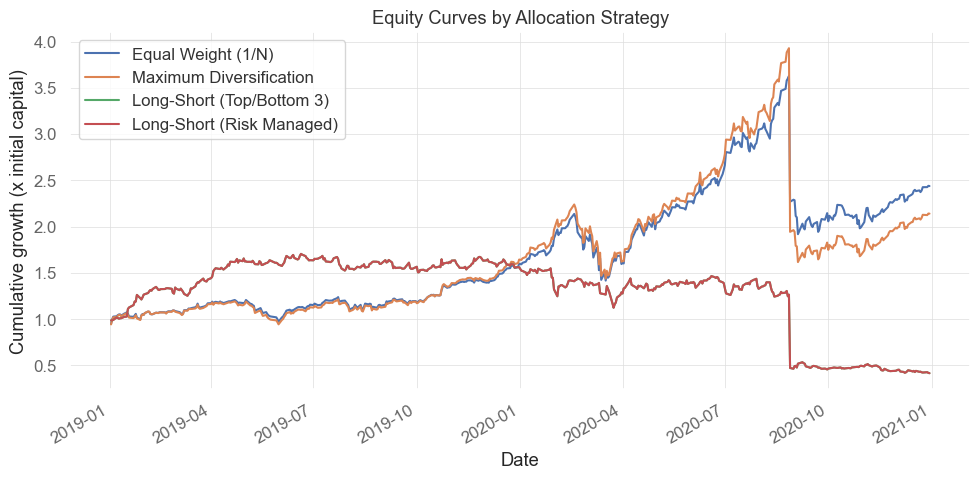

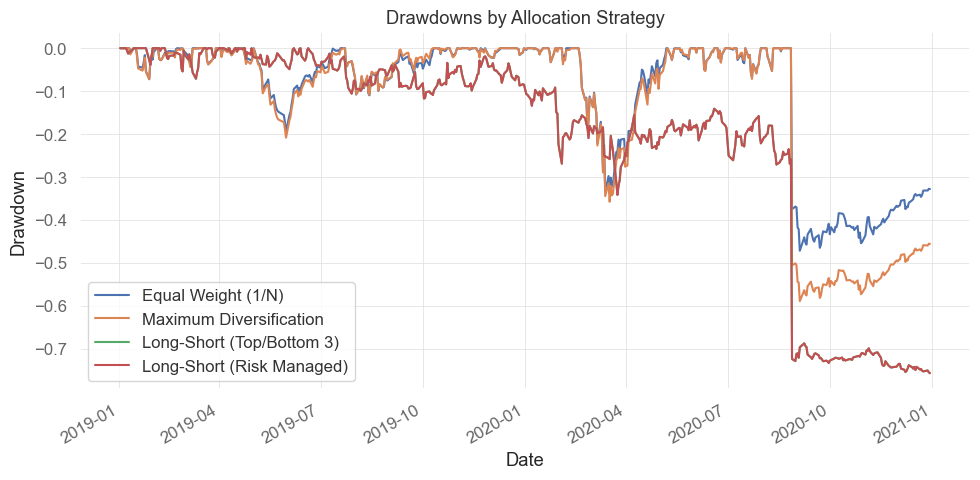

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
equity_curves.plot(ax=ax)
ax.set_title('Equity Curves by Allocation Strategy')
ax.set_ylabel('Cumulative growth (x initial capital)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
drawdowns.plot(ax=ax)
ax.set_title('Drawdowns by Allocation Strategy')
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()


In [96]:
from src.helpers._extract import ensure_dir
import quantstats as qs

strategy_label = 'Long-Short (Risk Managed)'
equity_series = equity_curves[strategy_label]
equity = equity_series.rename('Classifier Long-Short Equity')

strategy_rets = equity.pct_change(fill_method=None).dropna()
strategy_rets.name = 'Classifier Long-Short'

# Extract Fama-French factors from panel (same approach as main.ipynb)
# Use the renamed factor columns: rf and mktrf (not rf_lag1 and mktrf_lag1)
rf_by_date = (
    panel.reset_index()[["date", "rf"]]
    .dropna()
    .groupby("date", as_index=True)["rf"]
    .mean()
    .astype(float)
    .sort_index()
)

mktrf_by_date = (
    panel.reset_index()[["date", "mktrf"]]
    .dropna()
    .groupby("date", as_index=True)["mktrf"]
    .mean()
    .astype(float)
    .sort_index()
)

# Align all rows to strategy dates
rf_series = rf_by_date.reindex(strategy_rets.index).ffill().bfill()
bench_rets = (mktrf_by_date + rf_by_date).reindex(strategy_rets.index).ffill().bfill()
rf_series.name = "RiskFree"
bench_rets.name = "Market"

# Convert to excess returns (QS bug workaround: pass rf=0.0 to QS)
strategy_excess = (strategy_rets - rf_series).dropna()
bench_excess = (bench_rets - rf_series).reindex(strategy_excess.index).dropna()

# Ensure both series share the exact same dates
common_idx = strategy_excess.index.intersection(bench_excess.index)
strategy_excess = strategy_excess.reindex(common_idx)
bench_excess = bench_excess.reindex(common_idx)

ensure_dir('out')
qs.reports.html(
    strategy_excess,
    benchmark=bench_excess.to_frame('Market'),
    rf=0.0,
    periods_per_year=252,
    output='out/classifier_long_short_tearsheet.html',
    title='Classifier Probability-Based Long-Short Strategy',
)
print('QuantStats report saved to out/classifier_long_short_tearsheet.html')


QuantStats report saved to out/classifier_long_short_tearsheet.html


### Coefficient Inspection

In [97]:

coef_series = pd.Series(
    logit_pipeline.named_steps['logit'].coef_.ravel(),
    index=X_train.columns
)
coef_table = (
    pd.DataFrame({'coefficient': coef_series, 'abs_coef': coef_series.abs()})
    .sort_values('abs_coef', ascending=False)
)
coef_table


,coefficient,abs_coef
smb,0.134758,0.134758
adjclose_lag0,-0.123151,0.123151
umd,0.051679,0.051679
adjclose_lag3,0.032124,0.032124
ti_rsi_28,0.028814,0.028814
adj_mktcap,0.020778,0.020778
adjclose_lag2,-0.018952,0.018952
adjclose_lag1,0.015062,0.015062
ti_atr_20,0.013798,0.013798


### Test-Set Metrics

In [98]:

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

proba_test = logit_pipeline.predict_proba(X_test)[:, 1]
preds_test = (proba_test >= 0.5).astype(int)

metrics = {
    'accuracy': accuracy_score(y_test, preds_test),
    'precision': precision_score(y_test, preds_test),
    'recall': recall_score(y_test, preds_test),
    'f1': f1_score(y_test, preds_test),
    'roc_auc': roc_auc_score(y_test, proba_test),
}
metrics


{'accuracy': 0.5043650793650793,
 'precision': 0.5605483625285606,
 'recall': 0.5227272727272727,
 'f1': 0.5409775817714075,
 'roc_auc': 0.502509427117397}

In [99]:

conf_matrix = confusion_matrix(y_test, preds_test)
pd.DataFrame(conf_matrix, index=['Actual Sell (0)', 'Actual Buy (1)'], columns=['Pred Sell (0)', 'Pred Buy (1)'])


,Pred Sell (0),Pred Buy (1)
Actual Sell (0),535,577
Actual Buy (1),672,736


### Probability Distribution (Test Set)

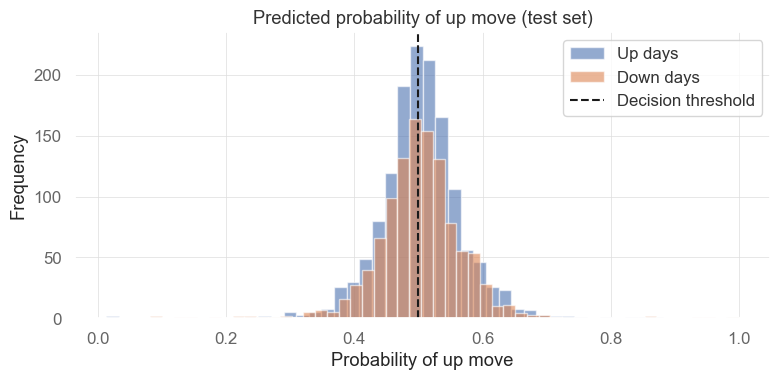

In [100]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(proba_test[y_test == 1], bins=50, alpha=0.6, label='Up days')
plt.hist(proba_test[y_test == 0], bins=50, alpha=0.6, label='Down days')
plt.axvline(0.5, color='k', linestyle='--', label='Decision threshold')
plt.title('Predicted probability of up move (test set)')
plt.xlabel('Probability of up move')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


In [101]:
display(logit_fit_metrics)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score

test_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, test_pred),
    'Balanced accuracy': balanced_accuracy_score(y_test, test_pred),
    'Precision': precision_score(y_test, test_pred, zero_division=0),
    'Recall': recall_score(y_test, test_pred, zero_division=0),
    'F1-score': f1_score(y_test, test_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, test_prob),
})

display(test_metrics.to_frame(name='Value'))
print('Classification report (test set):')
print(classification_report(y_test, test_pred, zero_division=0))
print('Confusion matrix (test set):')
print(confusion_matrix(y_test, test_pred))


,Metric,Value
0,Train accuracy,0.535258
1,Test accuracy,0.504365
2,Test baseline (majority class),0.558730


,Value
Accuracy,0.504365
Balanced accuracy,0.501921
Precision,0.560548
Recall,0.522727
F1-score,0.540978
ROC AUC,0.502509


Classification report (test set):
              precision    recall  f1-score   support

           0       0.44      0.48      0.46      1112
           1       0.56      0.52      0.54      1408

    accuracy                           0.50      2520
   macro avg       0.50      0.50      0.50      2520
weighted avg       0.51      0.50      0.51      2520

Confusion matrix (test set):
[[535 577]
 [672 736]]
